In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from src import plot, scaling, metrics, utils

In [3]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

runs_dir = PROJECT_ROOT / "runs-legacy"
with open(runs_dir / "data.json") as f:
    data = json.load(f)

runs = pd.DataFrame(data)

selected_obj = []
for obj in data:
    #if obj["dataset"] != "MuSiQue":
    #    continue
    #if obj["model"] != "gpt-4o":
    #    continue
    selected_obj.append(obj)

In [4]:
runs = pd.DataFrame(selected_obj)
runs.head()

,ID,dataset,model,prompt,csv_file
0,vy1n12lt,HotpotQA,DeepSeek-V3,cot,vy1n12lt.csv
1,uo2u5m33,HotpotQA,DeepSeek-V3,multistep,uo2u5m33.csv
2,5fdai5h7,HotpotQA,DeepSeek-V3,top-k,5fdai5h7.csv
3,71fhbj6s,MuSiQue,DeepSeek-V3,top-k,71fhbj6s.csv
4,nrs6ugxw,MuSiQue,DeepSeek-V3,direct,nrs6ugxw.csv


### Calculate Metrics

In [10]:
from tqdm import tqdm
from sklearn.metrics import auc
from collections import defaultdict

NUM_SPLITS = 5

def calculate_metrics(runs):
    metrics_list = []

    for i, row in tqdm(runs.iterrows(), total=len(runs)):
        csv_file = runs_dir / row["csv_file"]
        run_df = pd.read_csv(csv_file)
        y_true = run_df["gpt_eval"]
        y_confs = run_df["confidence"]

        skf = StratifiedKFold(n_splits=NUM_SPLITS, shuffle=True, random_state=42,)

        fold_metrics = defaultdict(list)

        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(y_confs, y_true)):
            # 1. Split the data
            y_train, y_test = y_true[train_idx],y_true[test_idx], 
            conf_train, conf_test = y_confs[train_idx], y_confs[test_idx], 

            #print(len(y_train), len(y_test))
        
            # 2. Calculate Metrics before
            ece = metrics.expected_calibration_error(y_test, conf_test)
            bs = metrics.brier_score_loss(y_test, conf_test)
            
            fold_metrics["ece"].append(ece)
            fold_metrics["brier"].append(bs)

            # Adjusting confs
            adj_confs, T = scaling.temperature_scaling(conf_train, conf_test, y_train, return_T = True)
            
            # 4. Calculate ECE After Scaling
            ece_t = metrics.expected_calibration_error(y_test, adj_confs)
            bs_t = metrics.brier_score_loss(y_test, adj_confs)
            
            fold_metrics["ece-t"].append(ece_t)
            fold_metrics["brier-t"].append(bs_t)
            fold_metrics["T"].append(T)

        #ece_values = metrics.bootstrap_ece(y_true, y_confs, n_bootstrap=100)
        m = {col: row[col] for col in ["ID", "dataset", "model", "prompt"]}

        m["acc"] = y_true.mean()
        m["auc"] = metrics.roc_auc_score(y_true, y_confs)
        m["num_samples"] = len(y_true)

        for col in fold_metrics:
            m[col] = fold_metrics[col]

        metrics_list.append(m)
    return pd.DataFrame(metrics_list)
        

In [ ]:
metrics_df = calculate_metrics(runs)
metrics_df = metrics_df.explode(["ece", "brier", "ece-t", "brier-t", "T"])
gpt_4o = metrics_df[metrics_df["model"] == "gpt-4o"]
#gpt_4o = runs
#calculate_metrics(gpt_4o)
gpt_4o

100%|██████████| 48/48 [00:35<00:00,  1.35it/s]


,ID,dataset,model,prompt,acc,auc,num_samples,ece,brier,ece-t,brier-t,T
24,1xowlg3z,MuSiQue,gpt-4o,multistep,0.358000,0.737067,1000,"[0.133689020625, 0.12790431500000005, 0.145189...","[0.20938435545338727, 0.18540416002429402, 0.2...","[0.1440331379221734, 0.21648759328936565, 0.15...","[0.23248230692390454, 0.2279584372660844, 0.23...","[4.4592825637882525, 5.964117687082129, 3.7798..."
25,gr7ngjjq,HotpotQA,gpt-4o,multistep,0.723000,0.782722,1000,"[0.15457543499999998, 0.18002506045, 0.1724250...","[0.19659965600024643, 0.16562383047869123, 0.1...","[0.1582304384050631, 0.2068046541070627, 0.178...","[0.19826085261452586, 0.18065747778003996, 0.1...","[1.1156502768083822, 1.6531974485742893, 1.085..."
26,j6kgohw0,MuSiQue,gpt-4o,cot,0.345000,0.709530,1000,"[0.465, 0.48750000000000004, 0.48425, 0.473500...","[0.42057500000000003, 0.447875, 0.4447625, 0.4...","[0.16721335852187577, 0.17253926551829032, 0.1...","[0.24797327573717826, 0.24875064966869243, 0.2...","[72.30592601928997, 58.06647062277502, 39.6454..."
27,ctewp0an,MuSiQue,gpt-4o,top-k,0.263000,0.699106,1000,"[0.5307499999999999, 0.5409999999999999, 0.544...","[0.45126250000000007, 0.4753, 0.47463750000000...","[0.24001354288329999, 0.24001468997288913, 0.2...","[0.2500024400034095, 0.2500058021107723, 0.250...","[30413.316997448448, 26882.849524764384, 28695..."
28,ao9rzbl6,2WikiMultihopQA,gpt-4o,cot,0.617000,0.744106,1000,"[0.22200000000000006, 0.256, 0.258250000000000...","[0.23650000000000002, 0.244625, 0.2563625, 0.2...","[0.09008175737607009, 0.07898625299869785, 0.0...","[0.20204442915074958, 0.18517651466614019, 0.1...","[8.32903045937462, 8.62373964860503, 8.3230125..."
29,a5nwxuu5,2WikiMultihopQA,gpt-4o,top-k,0.428000,0.622917,1000,"[0.3895, 0.4005, 0.39625000000000005, 0.39875,...","[0.3803, 0.3798, 0.39191249999999994, 0.405112...","[0.07512066040121879, 0.07509700871000494, 0.0...","[0.2499980939071255, 0.2499952419195072, 0.249...","[3456.5005536733274, 4532.550356680819, 3011.3..."
30,q8mly2jv,MuSiQue,gpt-4o,direct,0.268000,0.666353,1000,"[0.53575, 0.522, 0.518, 0.528, 0.533]","[0.4737375000000001, 0.44465000000000005, 0.45...","[0.23501896321683133, 0.23501952047802507, 0.2...","[0.25000664921797344, 0.2500018140902338, 0.25...","[21334.07597791971, 26900.43992218203, 22614.9..."
31,r8k9lo7u,2WikiMultihopQA,gpt-4o,direct,0.432000,0.565974,1000,"[0.3935000000000001, 0.40124999999999994, 0.40...","[0.39587500000000003, 0.40563750000000004, 0.3...","[0.07668466540708482, 0.0795985479269197, 0.07...","[0.250374587490781, 0.25107405109078906, 0.249...","[67.99029990260003, 49.73638053651917, 238.450..."
32,62vwtwzf,HotpotQA,gpt-4o,top-k,0.642000,0.780946,1000,"[0.23200000000000007, 0.22450000000000006, 0.2...","[0.244325, 0.25079999999999997, 0.2566275, 0.2...","[0.11335535890541319, 0.11408811526163011, 0.0...","[0.2031770248458138, 0.2067445936410018, 0.215...","[2.674678261814611, 2.6069866192929227, 2.3966..."
33,ul91s1f1,2WikiMultihopQA,gpt-4o,multistep,0.610000,0.739983,1000,"[0.10266478704687497, 0.08958658729999999, 0.1...","[0.20022936325579185, 0.1995360322223821, 0.20...","[0.12779943417129153, 0.10975918282267152, 0.1...","[0.20732162742551025, 0.20676991954847732, 0.2...","[2.2624559101609956, 2.3978303542851465, 1.853..."


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

metric_list = [["ece", "ece-t"], ["brier", "brier-t"], ["auc", "acc"]]
num_groups = len(metric_list)

def plot_metrics(df, hue="dataset", x="prompt", hue_order=None, x_order=None):
    if hue == "dataset" and hue_order is None:
        hue_order = ['HotpotQA', '2WikiMultihopQA', 'MuSiQue']
    elif hue_order is None:
        hue_order = sorted(df[hue].unique())

    if x == "prompt" and x_order is None:
        x_order =['multistep', 'cot', 'top-k', 'direct'] 
    elif x_order is None:
        x_order = sorted(df[x].unique())
    # 2. Styling and Configuration
    sns.set_theme(style="whitegrid")
    
    fig, axes = plt.subplots(num_groups, 2, figsize=(15, 6*num_groups),sharey=True)
    
    # Helper function to overlay pre-calculated SE error bars
    def add_error_bars(ax, data, x_col, y_col, hue_col, err_col, x_order, hue_order):
        n_hues = len(hue_order)
        width = 0.8 / n_hues 
        for i, hue in enumerate(hue_order):
            subset = data[data[hue_col] == hue].set_index(x_col).reindex(x_order)
            # Calculate precise X coordinates for the bars within the groups
            x_pos = np.arange(len(x_order)) + (i - (n_hues - 1) / 2) * width
            ax.errorbar(x_pos, subset[y_col], yerr=subset[err_col], 
                        fmt='none', c='black', capsize=4, elinewidth=1)
            
    for i, m_pair in enumerate(metric_list):
        # 3. Plot ECE
        for j, m in enumerate(m_pair):
            ax = axes[i,j]
            sns.barplot(data=df, x=x, y=m, hue=hue, 
                        order=x_order, hue_order=hue_order, ax=ax, palette="viridis")
            #if f'{m}_se' in df:
                #add_error_bars(ax, df, x, m, hue, f'{m}_se', x_order, hue_order)
            ax.set_title(m, fontsize=14)
            ax.set_ylabel(m)
            ax.set_xlabel('Prompt Technique')
    
    plt.tight_layout()
    plt.show()

In [19]:
metrics_df = metrics_df.explode(["ece", "brier", "ece-t", "brier-t", "T"])

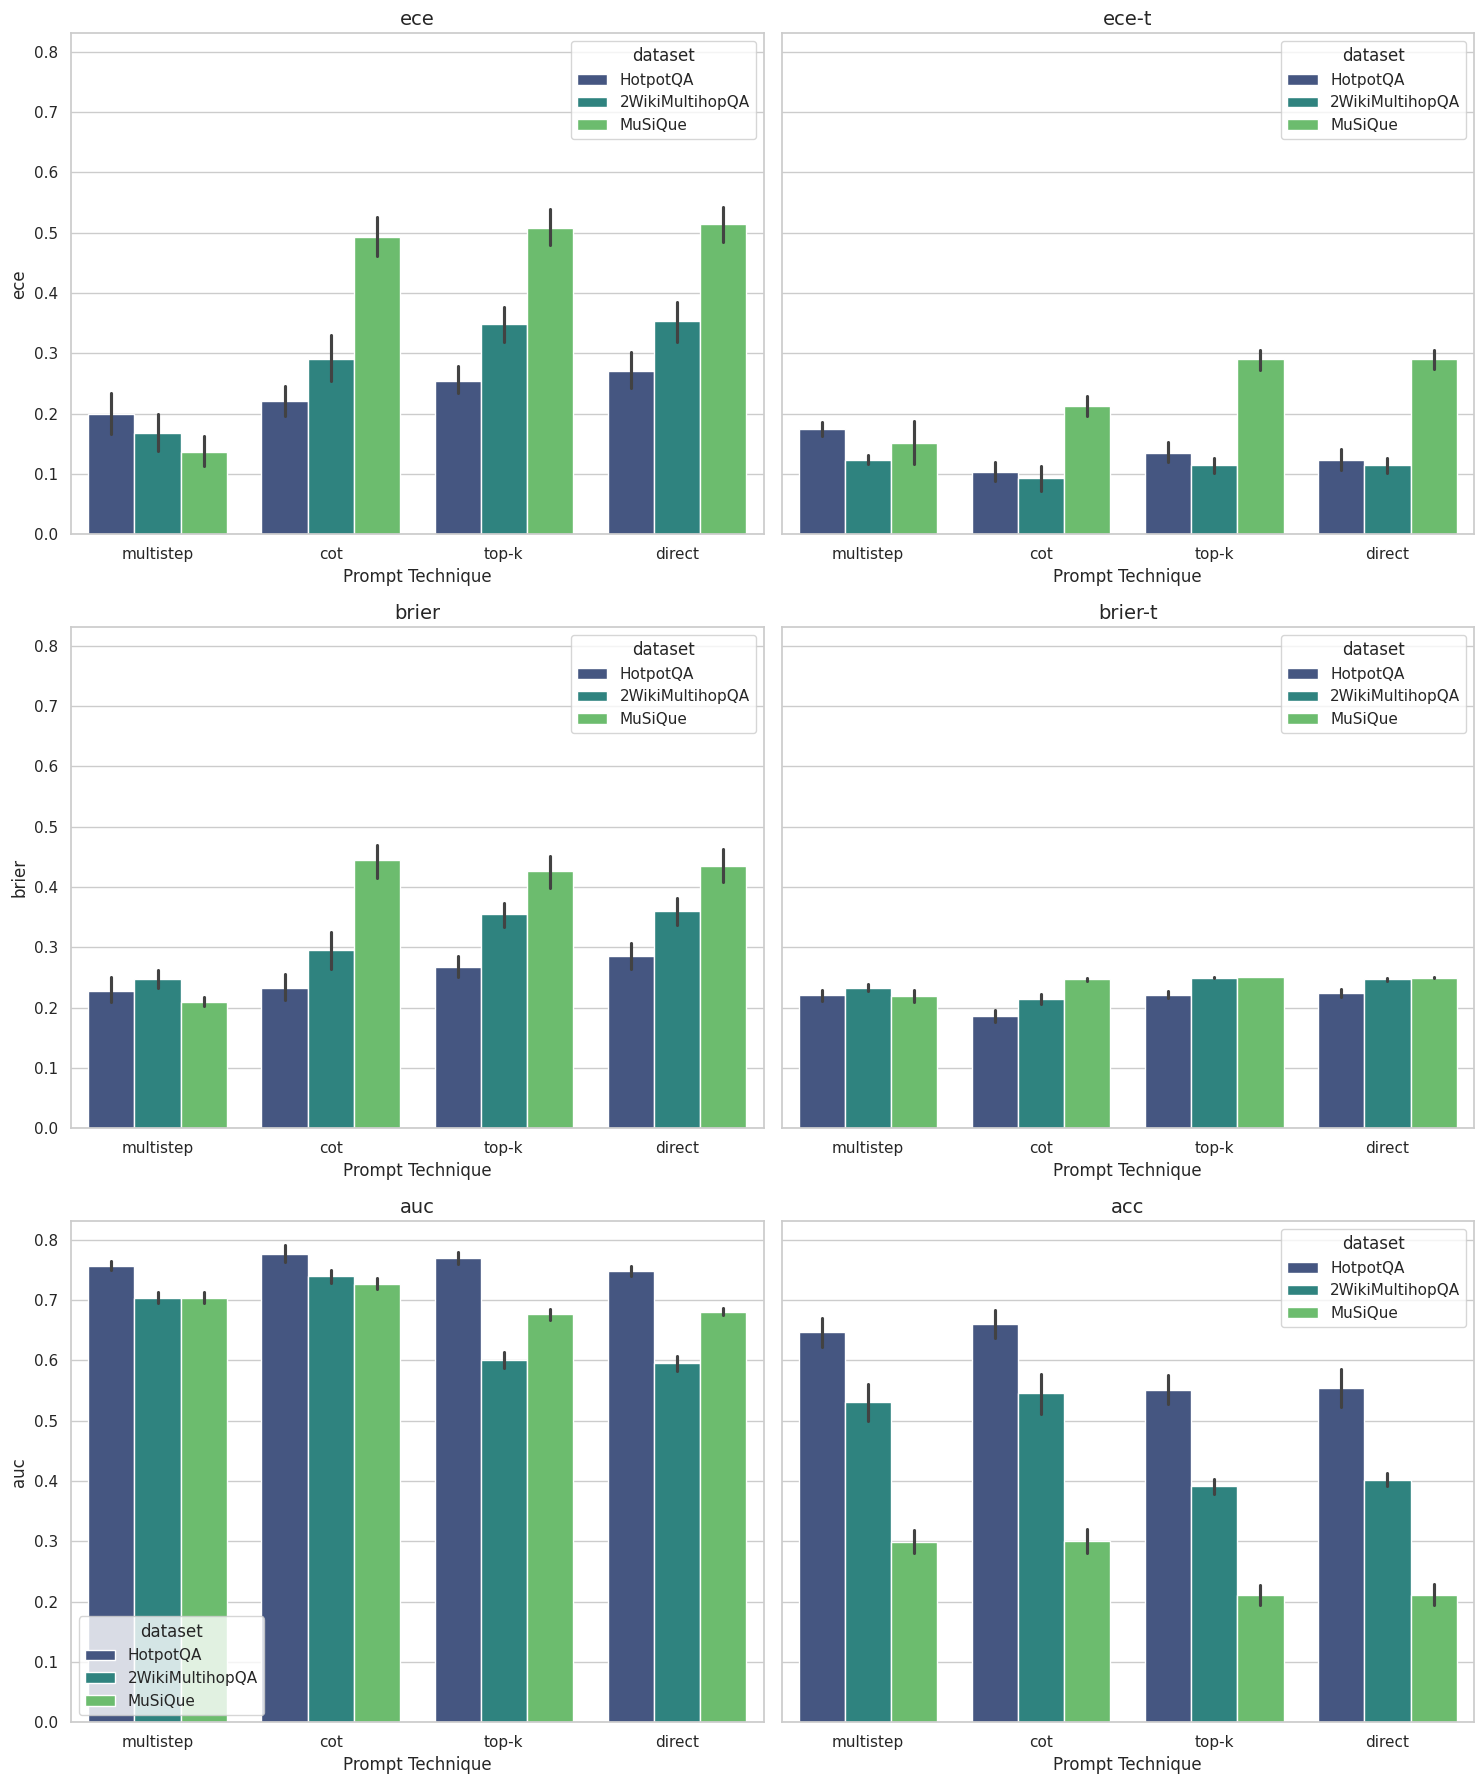

In [20]:
plot_metrics(metrics_df)

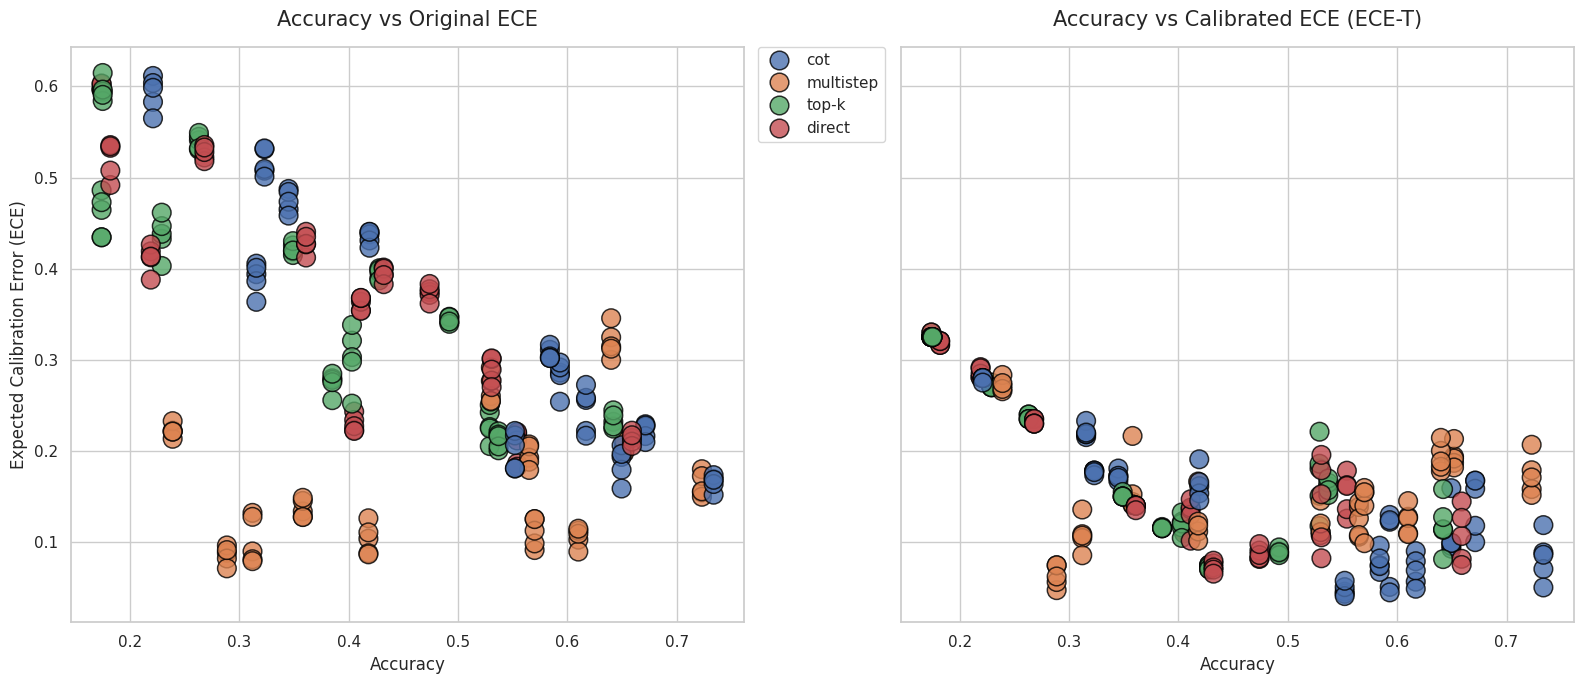

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_calibration_scatter(df):
    """
    Plots Accuracy vs ECE for both original and calibrated values.
    Ideal models appear in the bottom-right (High Accuracy, Low ECE).
    """
    # Setting the theme
    sns.set_theme(style="whitegrid")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)
    
    # Common aesthetic parameters
    scatter_kwargs = {
        'hue': 'prompt',
        's': 180,           # Marker size
        'alpha': 0.8,       # Transparency
        'edgecolor': 'black'
    }
    
    # Panel 1: Original ECE
    sns.scatterplot(data=df, x='acc', y='ece', ax=axes[0], **scatter_kwargs)
    axes[0].set_title('Accuracy vs Original ECE', fontsize=15, pad=15)
    axes[0].set_ylabel('Expected Calibration Error (ECE)', fontsize=12)
    axes[0].set_xlabel('Accuracy', fontsize=12)
    
    # Panel 2: Calibrated ECE (ece-t)
    # Ensure your dataframe has an 'ece_t' or 'ece-t' column
    sns.scatterplot(data=df, x='acc', y='ece-t', ax=axes[1], **scatter_kwargs)
    axes[1].set_title('Accuracy vs Calibrated ECE (ECE-T)', fontsize=15, pad=15)
    axes[1].set_xlabel('Accuracy', fontsize=12)
    
    # Place legend outside for clarity
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    axes[1].get_legend().remove() # Redundant
    
    plt.tight_layout()
    plt.show()

# To use it:
plot_calibration_scatter(metrics_df)

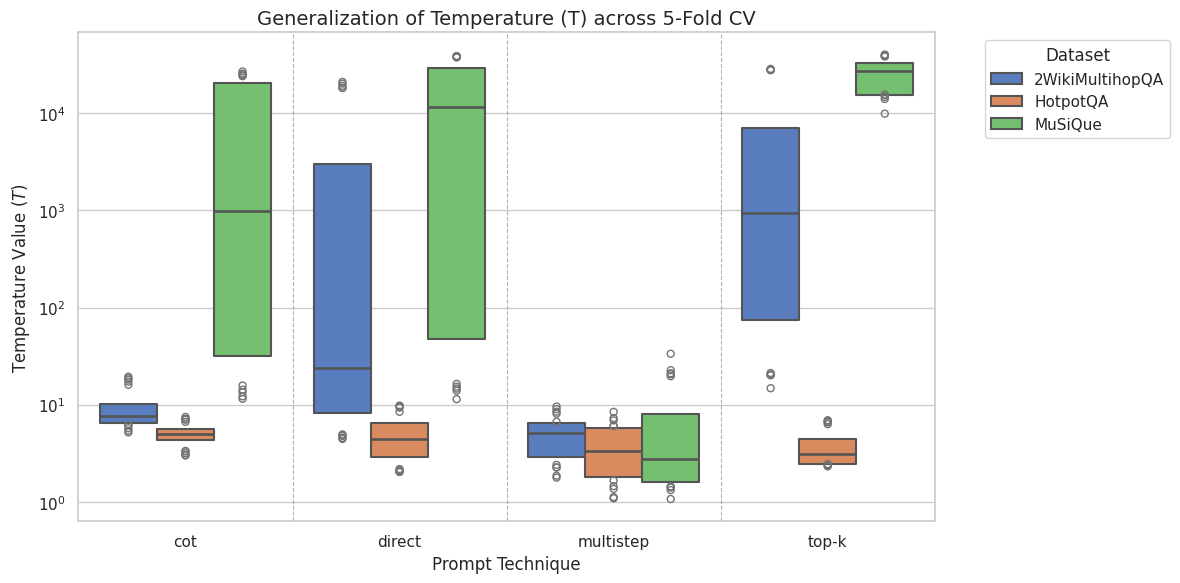

In [44]:
def plot_t_distribution(df, x="prompt", hue="dataset"):
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    order = sorted(df[x].unique())
    
    sns.boxenplot(
        data=df, 
        x=x, 
        y="T", 
        hue=hue, 
        linewidth=1.5,
        palette="muted",
        log_scale=True,
        hue_order=sorted(df[hue].unique()),
        order=order
    )
    
    # --- Add separators ---
    for i in range(len(order) - 1):
        plt.axvline(i + 0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    
    plt.title(f"Generalization of Temperature (T) across {NUM_SPLITS}-Fold CV", fontsize=14)
    plt.ylabel("Temperature Value ($T$)", fontsize=12)
    plt.xlabel("Prompt Technique", fontsize=12)
    plt.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


df_plot = runs.explode("T")
plot_t_distribution(df_plot, hue="dataset")

In [40]:
# create table of metrics mean + std
metric_table = metrics_df.groupby(["model", "dataset", "prompt"])[["acc", "ece", "brier", "ece-t", "brier-t", "auc"]].agg(['mean', 'std'])
# for each model export to csv
for model in metric_table.index.get_level_values(0).unique():
    model_table = metric_table.loc[model]
    model_table.to_csv(f"{model}_metrics_summary.csv")


## Ablation

In [37]:

from tqdm import tqdm
from sklearn.metrics import auc

NUM_SPLITS = 5

thisrow = None

def calculate_metrics_ablation(runs):
    metrics_list = []
    for i, row in tqdm(runs.iterrows(), total=len(runs)):
        csv_file = runs_dir / row["csv_file"]
        run_df = pd.read_csv(csv_file)
        y_true = run_df["gpt_eval"]
        for ab in range(10):
            new_row = row.to_dict()
            y_confs = run_df["confidence"]**ab
    
            skf = StratifiedKFold(n_splits=NUM_SPLITS, shuffle=True, random_state=42,)
    
            ece_values = []
            ece_t_values = []
            bs_t_values = []
            bs_values = []
            auc_values = []
            t_params = []
    
            for fold_idx, (train_idx, test_idx) in enumerate(skf.split(y_confs, y_true)):
                # 1. Split the data
                y_train, y_test = y_true[train_idx],y_true[test_idx], 
                conf_train, conf_test = y_confs[train_idx], y_confs[test_idx], 
    
                #print(len(y_train), len(y_test))
            
                # 2. Calculate Metrics before
                ece = metrics.expected_calibration_error(y_test, conf_test)
                bs = metrics.brier_score_loss(y_test, conf_test)
                
                ece_values.append(ece)
                bs_values.append(bs)
    
                # Adjusting confs
                adj_confs, T = scaling.temperature_scaling(conf_train, conf_test, y_train, return_T = True)
                
                # 4. Calculate ECE After Scaling
                ece_t = metrics.expected_calibration_error(y_test, adj_confs)
                bs_t = metrics.brier_score_loss(y_test, adj_confs)
                
                ece_t_values.append(ece_t)
                bs_t_values.append(bs_t)
                t_params.append(T)
    
            #ece_values = metrics.bootstrap_ece(y_true, y_confs, n_bootstrap=100)
            new_row.update({
                "ablation" : ab,
                "ece" :np.mean(ece_values),
                "ece_se" :np.std(ece_values),
                "brier" :np.mean(bs_values),
                "brier_se" :np.std(bs_values),
                "ece-t" :np.mean(ece_t_values),
                "ece-t_se" :np.std(ece_t_values),
                "brier-t" :np.mean(bs_t_values),
                "brier-t_se" :np.std(bs_t_values),
                "T" :t_params,
                "T_mean" :np.mean(t_params),
                "T_std" :np.std(t_params),
                "acc" :y_true.mean(),
                "auc" :metrics.roc_auc_score(y_true, y_confs),
                "num_samples" :len(y_true),
            })
            metrics_list.append(new_row)
    return pd.DataFrame(metrics_list)

ablation_runs = runs[runs["prompt"] == "cot"]
metrics_df = calculate_metrics_ablation(ablation_runs)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:22<00:00,  6.88s/it]


In [38]:
o4_metrics

,ID,dataset,model,prompt,csv_file,T,ece,ece_se,brier,brier_se,ece-t,ece-t_se,brier-t,brier-t_se,T_mean,T_std,acc,auc,num_samples,ablation
60,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
61,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
62,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
63,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
64,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
65,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
66,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
67,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
68,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9
69,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv,"[13.270434778518021, 11.95608174724696, 10.878...",0.141587,0.013943,0.234727,0.015139,0.174329,0.011982,0.229530,0.007992,12.052484,0.771971,0.345000,0.709530,1000,9


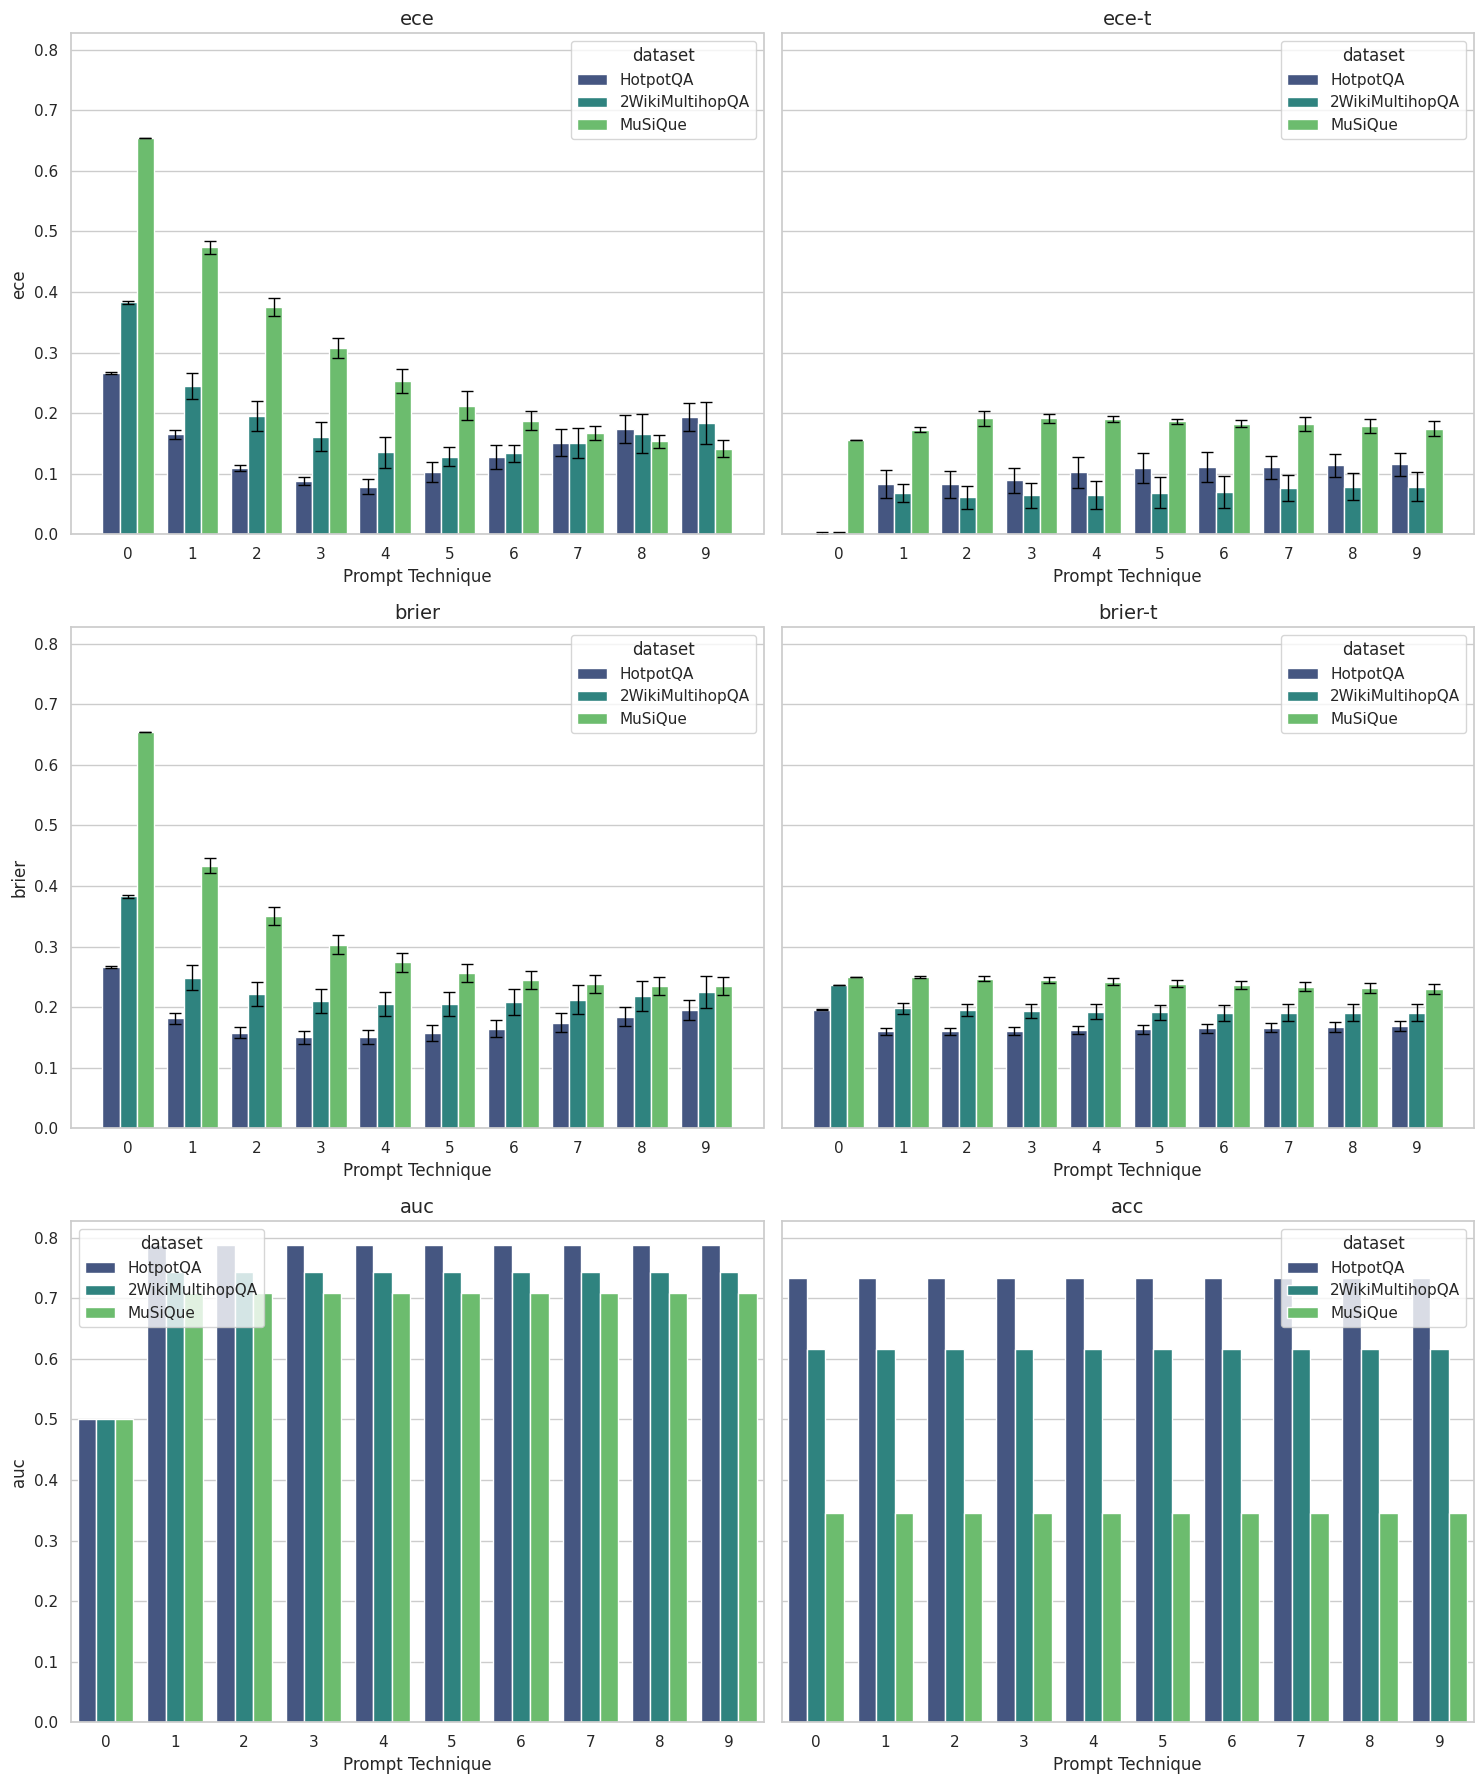

In [39]:
o4_metrics = metrics_df[metrics_df["model"] == "gpt-4o"]
plot_metrics(o4_metrics, x="ablation")

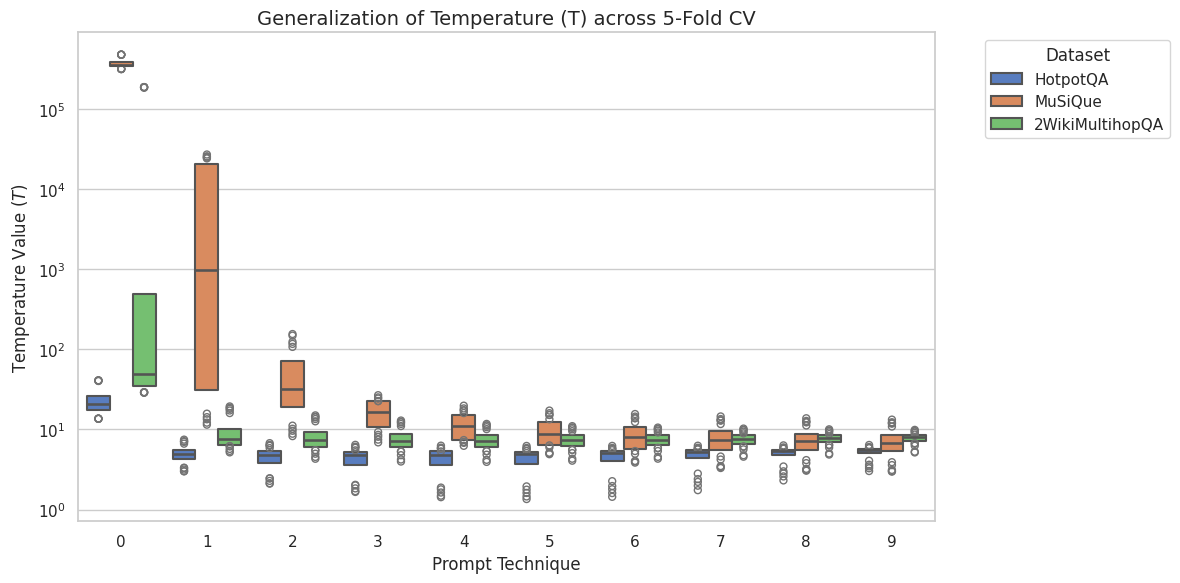

In [42]:
combined_plot_df = metrics_df.explode("T")
plot_t_distribution(combined_plot_df, x="ablation", )